# 目的変数の設計──分布変換と圧縮の落とし穴

Fe/Ni/Cr 合金データ（引張強度・硬さ）と腐食速度データを用いて、
目的変数設計における 3 つのポイントを実演します。

1. **対数変換の要否判断**──ヒストグラムと QQ プロットで確認  
2. **逆変換バイアスと Duan 補正**──単純な exp() は系統的に過小予測  
3. **目的変数の圧縮問題**──複数特性を 1 スコアに合成するとモデル精度が下がる

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 日本語フォント設定（macOS の場合）
plt.rcParams['font.family'] = 'Hiragino Sans'
plt.rcParams['axes.unicode_minus'] = False

import scipy.stats as stats
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

In [12]:
# Fe/Ni/Cr 合金データの生成（引張強度・硬さ）
np.random.seed(42)
n = 60

Ni      = np.random.uniform(5, 25, n)
Cr      = np.random.uniform(10, 20, n)
T_treat = np.random.uniform(900, 1100, n)   # 熱処理温度 [℃]
t_treat = np.random.uniform(0.5, 4.0, n)   # 保持時間 [h]
cool_r  = np.random.uniform(1, 50, n)      # 冷却速度 [℃/s]

# 目的変数①：引張強度（概ね正規分布）
tensile_strength = (
    500 + 1.5 * Ni + 2.0 * Cr
    + 0.3 * (T_treat - 1000)
    + 10 * np.log1p(t_treat)
    +  5 * np.log1p(cool_r)
    + np.random.normal(0, 20, n)
)

# 目的変数②：硬さ（引張強度に相関、独立ノイズ込み）
hardness = 0.28 * tensile_strength + np.random.normal(0, 15, n)

# 「圧縮スコア」の例：TS と HV を標準化して合算（悪い設計）
ts_z = (tensile_strength - tensile_strength.mean()) / tensile_strength.std()
hv_z = (hardness - hardness.mean()) / hardness.std()
composite_score = ts_z + hv_z

X_cols = ['Ni', 'Cr', 'T_treat', 't_treat', 'cool_r']
df = pd.DataFrame({'Ni': Ni, 'Cr': Cr, 'T_treat': T_treat,
                   't_treat': t_treat, 'cool_r': cool_r,
                   'tensile_strength': tensile_strength,
                   'hardness': hardness,
                   'composite_score': composite_score})

print(f"サンプル数: {n}")
print(df[['tensile_strength', 'hardness', 'composite_score']].describe().round(1))

サンプル数: 60
       tensile_strength  hardness  composite_score
count              60.0      60.0             60.0
mean              575.1     162.5              0.0
std                35.0      15.7              1.8
min               494.8     136.9             -3.2
25%               546.1     149.8             -1.5
50%               575.2     164.1             -0.0
75%               594.5     172.7              0.9
max               664.0     203.3              5.2


## Section 1　目的変数の分布を確認する

機械学習を始める前に、目的変数の**分布形状**を確認します。  
正規分布から大きく外れている場合は、対数変換などの前処理が必要になります。

確認ツール：
- **ヒストグラム**──右歪み（右に裾が長い）なら対数変換を検討
- **QQ プロット**──理論正規分布と実データのずれを視覚化（**形を見る**。相関係数 r だけで判断しない）

読み方の注意：r は右歪み・左歪みのどちらでも下がりうる。QQ プロットで**どの裾が外れているか**を確認してから変換を選びます。

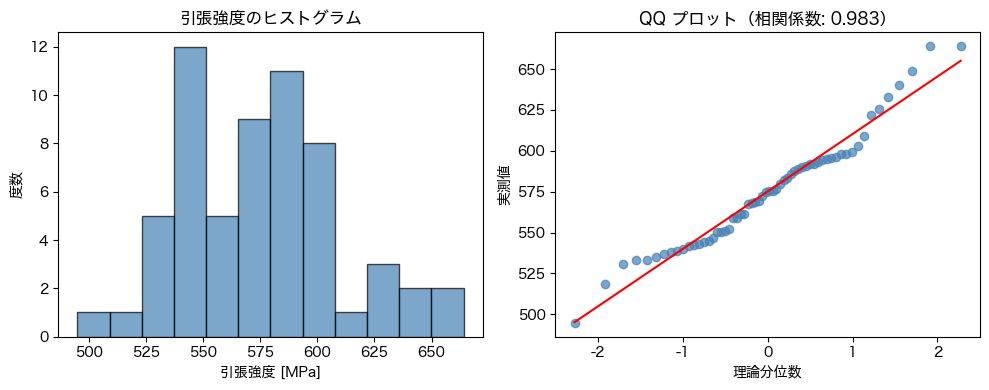

QQ 相関係数 r = 0.983  → 0.98 以上ならほぼ正規分布
右歪みは弱く、QQ プロット中央に軽い波打ちあり → 完全な正規ではないが対数変換は不要


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# ヒストグラム
axes[0].hist(tensile_strength, bins=12, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('引張強度 [MPa]')
axes[0].set_ylabel('度数')
axes[0].set_title('引張強度のヒストグラム')

# QQ プロット
(osm, osr), (slope, intercept, r_ts) = stats.probplot(tensile_strength, dist='norm')
axes[1].plot(osm, osr, 'o', color='steelblue', alpha=0.7)
axes[1].plot(osm, slope * np.array(osm) + intercept, 'r-')
axes[1].set_xlabel('理論分位数')
axes[1].set_ylabel('実測値')
axes[1].set_title(f'QQ プロット（相関係数: {r_ts:.3f}）')

plt.tight_layout()
plt.savefig('sec1_dist_tensile.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"QQ 相関係数 r = {r_ts:.3f}  → 0.98 以上ならほぼ正規分布")
print("右歪みは弱く、QQ プロット中央に軽い波打ちあり → 完全な正規ではないが対数変換は不要")

## Section 2　対数変換が有効なケース

腐食速度（μm/year）のような物性値は、数十倍〜数百倍にわたって変化します。  
このような変数をそのまま目的変数にすると、大きな値のサンプルに損失関数が支配されます。

**対数変換が必要な目安：**
- ヒストグラムが右に裾を引く形（**右歪み**）
- 変数の範囲が 1〜2 桁以上に及ぶ
- QQ プロット相関係数が 0.95 未満

**読み方の注意：**
- QQ の相関係数 r は「直線からのズレの大きさ」の目安。右歪み・左歪みのどちらでも下がりうる
- **変換の種類は QQ プロットの形で決める**（右裾が上に外れる → 対数、左裾が下に外れる → log は不向き）
- r が 0.95 以上でも中央の波打ちがあれば完全な正規ではない（Section 1 の引張強度）。その場合は変換不要なことも多い

⚠️ ゼロや負の値を含む場合は `log1p(y)` か **Yeo-Johnson 変換**を使います。  
左歪みの場合は対数変換ではなく、Yeo-Johnson や Box-Cox で λ を変える。

In [14]:
# 腐食速度データ（対数正規分布）
np.random.seed(0)
m = 50

Ni_c  = np.random.uniform(5, 25, m)
Cr_c  = np.random.uniform(10, 20, m)
pH    = np.random.uniform(3, 7, m)
T_env = np.random.uniform(20, 80, m)

# 腐食速度は自然界では対数正規分布に従いやすい
log_cr = (
    2.0 - 0.15 * Cr_c + 0.05 * Ni_c
    + 0.5 * (7 - pH) + 0.02 * T_env
    + np.random.normal(0, 0.4, m)
)
corrosion_rate = np.exp(log_cr)   # μm/year

print(f"腐食速度: 最小 {corrosion_rate.min():.1f}, 最大 {corrosion_rate.max():.1f} μm/year")
print(f"レンジ比: {corrosion_rate.max() / corrosion_rate.min():.0f} 倍（→ 対数変換を検討）")

腐食速度: 最小 1.3, 最大 84.8 μm/year
レンジ比: 63 倍（→ 対数変換を検討）


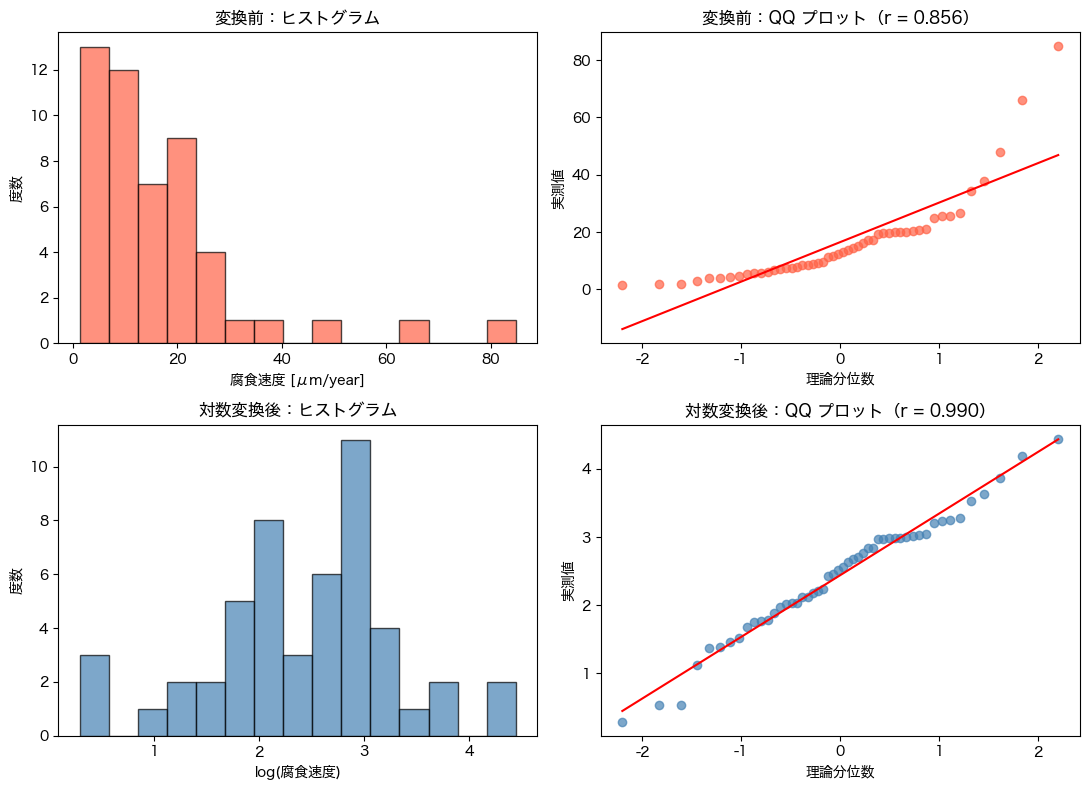

QQ 相関係数: 変換前 0.856 → 対数変換後 0.990
対数変換によって正規性が大きく改善しています。


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

# 変換前 ─────────────────────────────────
axes[0, 0].hist(corrosion_rate, bins=15, edgecolor='black', alpha=0.7, color='tomato')
axes[0, 0].set_xlabel('腐食速度 [μm/year]')
axes[0, 0].set_ylabel('度数')
axes[0, 0].set_title('変換前：ヒストグラム')

(osm, osr), (slope, intercept, r_raw) = stats.probplot(corrosion_rate, dist='norm')
axes[0, 1].plot(osm, osr, 'o', color='tomato', alpha=0.7)
axes[0, 1].plot(osm, slope * np.array(osm) + intercept, 'r-')
axes[0, 1].set_xlabel('理論分位数')
axes[0, 1].set_ylabel('実測値')
axes[0, 1].set_title(f'変換前：QQ プロット（r = {r_raw:.3f}）')

# 変換後 ─────────────────────────────────
axes[1, 0].hist(log_cr, bins=15, edgecolor='black', alpha=0.7, color='steelblue')
axes[1, 0].set_xlabel('log(腐食速度)')
axes[1, 0].set_ylabel('度数')
axes[1, 0].set_title('対数変換後：ヒストグラム')

(osm, osr), (slope, intercept, r_log) = stats.probplot(log_cr, dist='norm')
axes[1, 1].plot(osm, osr, 'o', color='steelblue', alpha=0.7)
axes[1, 1].plot(osm, slope * np.array(osm) + intercept, 'r-')
axes[1, 1].set_xlabel('理論分位数')
axes[1, 1].set_ylabel('実測値')
axes[1, 1].set_title(f'対数変換後：QQ プロット（r = {r_log:.3f}）')

plt.tight_layout()
plt.savefig('sec2_log_transform.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"QQ 相関係数: 変換前 {r_raw:.3f} → 対数変換後 {r_log:.3f}")
print("対数変換によって正規性が大きく改善しています。")

In [16]:
# Ridge 回帰で元スケール vs 対数スケールの LOOCV R² を比較
X_c  = np.column_stack([Ni_c, Cr_c, pH, T_env])
X_cs = StandardScaler().fit_transform(X_c)
loo  = LeaveOneOut()

# 元スケールで学習・評価
y_pred_raw = cross_val_predict(Ridge(alpha=1.0), X_cs, corrosion_rate, cv=loo)
r2_raw     = r2_score(corrosion_rate, y_pred_raw)

# 対数スケールで学習 → 逆変換して評価
log_pred_loo = cross_val_predict(Ridge(alpha=1.0), X_cs, log_cr, cv=loo)
y_pred_exp   = np.exp(log_pred_loo)
r2_log       = r2_score(corrosion_rate, y_pred_exp)

print(f"元スケールで学習    LOOCV R² = {r2_raw:.3f}")
print(f"対数スケールで学習  LOOCV R² = {r2_log:.3f}")
print()
print("対数変換後にモデルを構築することで予測精度が向上します。")

元スケールで学習    LOOCV R² = 0.424
対数スケールで学習  LOOCV R² = 0.513

対数変換後にモデルを構築することで予測精度が向上します。


## Section 3　逆変換バイアスと Duan 補正

対数空間で学習したモデルの予測値 $\hat{z}$ を元のスケールに戻す際、  
単純に $\exp(\hat{z})$ を適用すると **系統的な過小予測（バイアス）** が生じます。

**理由（Jensen の不等式）**：  
$\exp$ は上に凸なので $E[\exp(Z)] > \exp(E[Z])$ が成り立ちます。  
残差 $\varepsilon \sim \mathcal{N}(0, \sigma^2)$ があると、

$$E[y] = E[\exp(z + \varepsilon)] = \exp(z) \cdot \exp\!\left(\frac{\sigma^2}{2}\right)$$

**Duan の smearing 補正（残差が正規分布に従う場合）**：
$$\hat{y}_{\text{corrected}} = \exp\!\left(\hat{z} + \frac{\hat{\sigma}^2}{2}\right)$$

$\hat{\sigma}^2$ は対数空間での訓練残差の分散です。

**バイアスの見方**：Jensen バイアスは **平均レベル** `mean(予測) / mean(実測)` で確認します。  
サンプルごとの `mean(予測/実測)` は実測が小さい点で膨らみやすく、補正の効果を誤って評価しがちです。

In [17]:
# LOOCV で逆変換バイアスを実証
log_preds_loo = np.zeros(m)
sigma2_per_fold = np.zeros(m)

for train_idx, test_idx in LeaveOneOut().split(X_cs):
    X_tr, X_te = X_cs[train_idx], X_cs[test_idx]
    y_tr = log_cr[train_idx]
    mdl  = Ridge(alpha=1.0).fit(X_tr, y_tr)
    log_preds_loo[test_idx] = mdl.predict(X_te)
    res = y_tr - mdl.predict(X_tr)
    sigma2_per_fold[test_idx] = res.var()

sigma2_est = sigma2_per_fold.mean()
duan_factor = np.exp(sigma2_est / 2)

y_naive = np.exp(log_preds_loo)
y_duan  = np.exp(log_preds_loo + sigma2_est / 2)

def level_ratio(y_pred):
    """平均レベルのバイアス（Duan 補正が直す対象）"""
    return y_pred.mean() / corrosion_rate.mean()

ratio_naive_level = level_ratio(y_naive)
ratio_duan_level  = level_ratio(y_duan)
ratio_naive_ptwise = (y_naive / corrosion_rate).mean()
ratio_duan_ptwise  = (y_duan  / corrosion_rate).mean()

print(f"推定 σ²（対数空間・訓練残差の平均）= {sigma2_est:.4f}")
print(f"  → Duan 補正係数 exp(σ²/2) = {duan_factor:.4f}")
print()
print("【主指標】平均レベル mean(予測) / mean(実測)  ← Jensen バイアスの確認に使う")
print(f"  補正なし（単純 exp）: {ratio_naive_level:.3f}  （1 未満 → 系統的過小）")
print(f"  Duan 補正後:          {ratio_duan_level:.3f}  （1 に近いほどバイアス小）")
print()
print("【参考】mean(予測/実測) は実測が小さい点ほど膨らみやすい指標")
print(f"  補正なし {ratio_naive_ptwise:.3f} → Duan 後 {ratio_duan_ptwise:.3f}")
print("  → 点ごとの比率だけ見ると補正が逆効果に見えることもある")

推定 σ²（対数空間・訓練残差の平均）= 0.1520
  → Duan 補正係数 exp(σ²/2) = 1.0790

【主指標】平均レベル mean(予測) / mean(実測)  ← Jensen バイアスの確認に使う
  補正なし（単純 exp）: 0.937  （1 未満 → 系統的過小）
  Duan 補正後:          1.011  （1 に近いほどバイアス小）

【参考】mean(予測/実測) は実測が小さい点ほど膨らみやすい指標
  補正なし 1.100 → Duan 後 1.187
  → 点ごとの比率だけ見ると補正が逆効果に見えることもある


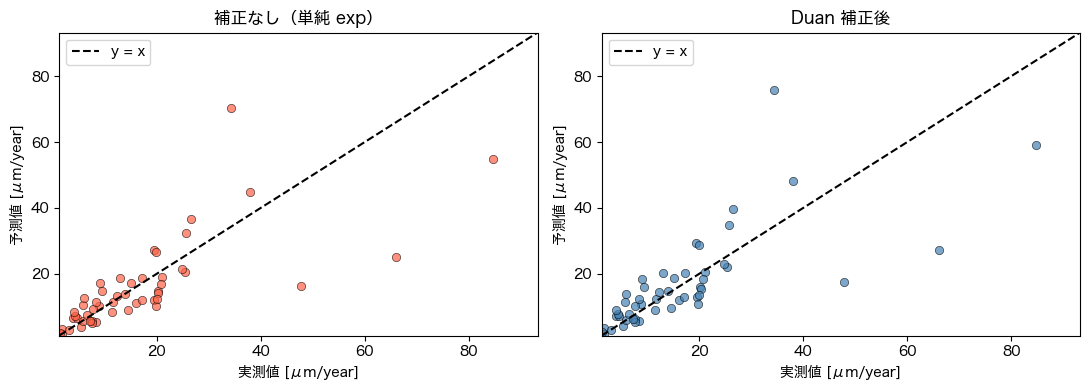

左右で点の並びはほぼ同じ（Duan 補正は各点を同じ比率で持ち上げるだけ）。
平均レベルのバイアス改善は、上の数値セルで確認する。


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, y_pred, title, color in zip(
    axes,
    [y_naive, y_duan],
    ['補正なし（単純 exp）', 'Duan 補正後'],
    ['tomato', 'steelblue']
):
    ax.scatter(corrosion_rate, y_pred, alpha=0.7, color=color, edgecolors='k', linewidths=0.5)
    mn = min(corrosion_rate.min(), y_pred.min()) * 0.9
    mx = max(corrosion_rate.max(), y_pred.max()) * 1.1
    ax.plot([mn, mx], [mn, mx], 'k--', label='y = x')
    ax.set_xlim(mn, mx)
    ax.set_ylim(mn, mx)
    ax.set_xlabel('実測値 [μm/year]')
    ax.set_ylabel('予測値 [μm/year]')
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.savefig('sec3_duan_correction.png', dpi=120, bbox_inches='tight')
plt.show()

print("左右で点の並びはほぼ同じ（Duan 補正は各点を同じ比率で持ち上げるだけ）。")
print("平均レベルのバイアス改善は、上の数値セルで確認する。")

## Section 4　目的変数の「圧縮」問題

複数の特性（例：引張強度・硬さ）をドメイン知識で合成した「総合スコア」を  
目的変数にするアプローチは**避けるべき**です。

**理由**：
- 個々の物性値と特徴量のマッピングは比較的シンプル → モデルが学習しやすい
- 合成スコアへのマッピングは非線形で複雑になり、予測精度が下がる
- 「スコアが高い」の物理的解釈が不明確になる

**推奨**：目的変数は物理的に純粋な単位で個別に予測し、  
複合評価はパレート最適化などの**後処理**に委ねる。

In [19]:
# 引張強度・硬さ・圧縮スコアの LOOCV R² を比較
X_alloy   = df[X_cols].values
X_alloy_s = StandardScaler().fit_transform(X_alloy)
loo       = LeaveOneOut()

targets = [
    ('引張強度 [MPa]',      tensile_strength),
    ('硬さ [HV]',           hardness),
    ('圧縮スコア（TS+HV）', composite_score),
]

for name, y in targets:
    y_pred  = cross_val_predict(Ridge(alpha=1.0), X_alloy_s, y, cv=loo)
    r2      = r2_score(y, y_pred)
    print(f"{name:26s}  LOOCV R² = {r2:.3f}")

print()
print("→ 引張強度単体（0.626）に比べ、圧縮スコア（0.466）は低下。")
print("  最も予測しやすい物性の構造を壊して中間の精度に落ちる。")

引張強度 [MPa]                  LOOCV R² = 0.626
硬さ [HV]                     LOOCV R² = 0.187
圧縮スコア（TS+HV）                LOOCV R² = 0.466

→ 圧縮スコアは個別物性値より R² が低下します。
  合成によって「モデルが捉えやすい構造」が崩れるためです。


## まとめ

| ポイント | 判断基準 | 対処法 |
|---|---|---|
| 対数変換の要否 | ヒストグラムが右歪み / QQ 相関係数 < 0.95 | `np.log(y)` で変換してから学習 |
| 逆変換バイアス | 対数空間で学習した場合は必ず発生 | `exp(ŷ + σ²/2)` で Duan 補正（効果は `mean(予測)/mean(実測)` で確認） |
| 圧縮スコアの回避 | 複数物性を 1 指標に合算している場合 | 個別に予測し、後処理でパレート最適化 |

**次のノートブックでは**、特徴量の設計・選択と  
Pipeline によるデータリーク防止を扱います。